# 📘 Clase 2: Proyecto de Machine Learning y Regresión Lineal

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/4/4f/FIUNA_logo.png/200px-FIUNA_logo.png" width="150" align="right">

**Facultad de Ingeniería de la Universidad Nacional de Asunción**  
**Curso:** Inteligencia Artificial 2026  
**Profesores:** Diego Stalder (Teoría) & Christian Torres (Práctica)  

---

## 📌 Objetivos de la Clase

1. Comprender las fases de un proyecto de Machine Learning
2. Aplicar la regresión lineal como modelo predictivo
3. Implementar la solución de Mínimos Cuadrados Ordinarios (OLS)
4. Visualizar resultados con Matplotlib
5. Diferenciar entre regresión simple y múltiple
6. Entender el problema del sobreajuste (overfitting)

## 1. 🔬 Seminario: IA aplicada a Previsión de Demanda Eléctrica

### Contexto del Problema

<img src="https://www.ssme.gov.py/vmme/images/noticias/2022/demanda_potencia.jpg" width="600">

La **Administración Nacional de Electricidad (ANDE)** registra constantemente nuevos picos de demanda de potencia. Por ejemplo, recientemente se superaron los **4.744 MW** de demanda.

**Pregunta:** ¿Podemos predecir la demanda futura utilizando datos históricos y variables externas?

---

### 🔍 Selección de Atributos (Feature Selection)

Para predecir la demanda eléctrica, se consideran:

*   📊 Histórico de demanda eléctrica
*   🌡️ Variables meteorológicas (temperatura, humedad, velocidad del viento)
*   📅 Variables del calendario (año, mes, día de la semana, feriados)

**Ejemplo de Patrones:**
```
Demanda (MW) vs Hora del día
2000 |    *
1900 |   * *
1800 |  *   *
1700 | *     *
1600 |*
     +----------------
      00:00   20:00
```

---

### 🧹 Limpieza de Datos

**Método de las 3 sigmas** para detección de outliers:

```
Si |x - μ| > 3σ → posible outlier
```

<img src="https://www.researchgate.net/publication/338717299/figure/fig4/AS:850938994094080@1580123109691/Three-sigma-method-applied-to-Original-SIN-with-different-window-length-values.png" width="500">

---

### 🧠 Modelo de Predicción

**Ventana de retrospección (w) y horizonte de predicción (h):**

```
       w (datos pasados)        h (futuro)
|------------------------|----------------|
t-w                      t               t+h
```

**Métricas de evaluación:**
*   MSE (Error Cuadrático Medio)
*   RMSE (Raíz del Error Cuadrático Medio)
*   R² (Coeficiente de determinación)
*   Error al 95% (Percentil 95 del error)

## 2. 📈 Regresión Lineal

### 2.1 Conceptos Fundamentales

La regresión lineal modela la relación entre una variable dependiente $y$ y una o más variables independientes $x$ mediante una ecuación lineal:

**Regresión Lineal Simple:**
$$ y = w_1 x + w_0 + \epsilon $$

Donde:
*   $w_1$: pendiente (coeficiente)
*   $w_0$: intersección (bias)
*   $\epsilon$: error (ruido)

**Regresión Lineal Múltiple:**
$$ y = w_1 x_1 + w_2 x_2 + ... + w_n x_n + w_0 $$

---

### 2.2 Mínimos Cuadrados Ordinarios (OLS)

El objetivo es minimizar la suma de los errores cuadráticos:

$$ F(w) = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

Para un conjunto de puntos $(x_1, y_1), (x_2, y_2), (x_3, y_3)$, tenemos:

$$ F(w) = (y_1 - w_1x_1 - w_0)^2 + (y_2 - w_1x_2 - w_0)^2 + (y_3 - w_1x_3 - w_0)^2 $$

Para minimizar, derivamos e igualamos a cero:

$$ \frac{dF}{dw_1} = -2x_1(y_1 - w_1x_1 - w_0) - 2x_2(y_2 - w_1x_2 - w_0) - 2x_3(y_3 - w_1x_3 - w_0) = 0 $$

$$ \frac{dF}{dw_0} = -2(y_1 - w_1x_1 - w_0) - 2(y_2 - w_1x_2 - w_0) - 2(y_3 - w_1x_3 - w_0) = 0 $$

---

### 2.3 Formulación Matricial

Podemos reescribir el sistema como:

$$ A^T A w = A^T b $$

Donde:

$$ A = \begin{bmatrix} 1 & x_1 \\ 1 & x_2 \\ 1 & x_3 \end{bmatrix} \quad
   w = \begin{bmatrix} w_0 \\ w_1 \end{bmatrix} \quad
   b = \begin{bmatrix} y_1 \\ y_2 \\ y_3 \end{bmatrix} $$

La solución analítica es:

$$ w = (A^T A)^{-1} A^T b $$

---

### 2.4 Coeficiente de Determinación ($R^2$)

Mide la bondad del ajuste:

$$ R^2 = 1 - \frac{SS_{RES}}{SS_{TOT}} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} $$

---

### 2.5 Regresión Polinomial

Extensión de la regresión lineal para relaciones no lineales:

$$ y = w_0 + w_1 x + w_2 x^2 + ... + w_n x^n $$

**Ejemplo:**

| Orden | Ecuación |
|:---:|:---|
| 1 | $\theta_0 + \theta_1 x$ |
| 3 | $\theta_0 + \theta_1 x + \theta_2 x^2 + \theta_3 x^3$ |
| 9 | Polinomio de grado 9 |

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_polynomial_interpolation_001.png" width="600">

**Problema del sobreajuste (overfitting):** A mayor grado, mayor riesgo de ajustar el ruido.

## 3. 🛠️ Implementación Práctica con Python

### 3.1 Configuración Inicial

In [21]:
# Importar librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

# Configuración para gráficos más profesionales
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Semilla para reproducibilidad
np.random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


### 3.2 Generación de Datos Sintéticos

Generaremos datos con una relación lineal conocida: $y = 3 + 2x + \text{ruido}$

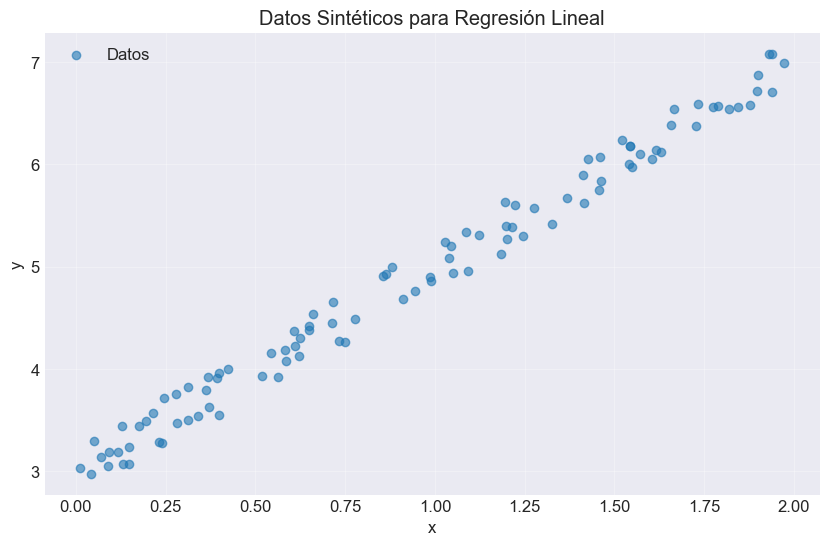

Rango de x: [0.01, 1.97]


In [22]:
# Número de muestras
N = 100

# Variable independiente (característica)
x = 2 * np.random.rand(N, 1)

# Variable dependiente con relación lineal + ruido
# y = 3 + 2*x + ruido (uniforme entre -0.25 y 0.25)
y = 3 + 2 * x + (0.5 * np.random.rand(N, 1) - 0.25)

# Visualización de los datos generados
plt.scatter(x, y, alpha=0.6, label='Datos')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos Sintéticos para Regresión Lineal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Rango de x: [{np.min(x):.2f}, {np.max(x):.2f}]")

### 3.3 Construcción de la Matriz de Diseño

Para incluir el término independiente ($w_0$), añadimos una columna de unos a la matriz $A$.

In [23]:
# Añadir columna de unos para el intercepto
unos = np.ones((N, 1))
A = np.hstack((unos, x))  # Matriz de diseño: [1, x]
b = y                     # Vector objetivo

print("Matriz de diseño A (primeras 5 filas):")
print(A[:5])
print("\nForma de A:", A.shape)
print("Forma de b:", b.shape)

Matriz de diseño A (primeras 5 filas):
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]
 [1.         1.19731697]
 [1.         0.31203728]]

Forma de A: (100, 2)
Forma de b: (100, 1)


### 3.4 Solución de Mínimos Cuadrados (OLS)

Aplicamos la fórmula: $w = (A^T A)^{-1} A^T b$

In [24]:
# Calcular A^T A
AtA = np.matmul(np.transpose(A), A)

# Calcular inversa de A^T A
invAtA = np.linalg.inv(AtA)

# Calcular A^T b
Atb = np.matmul(np.transpose(A), b)

# Calcular coeficientes w = (A^T A)^-1 * A^T b
w = np.matmul(invAtA, Atb)

print("Coeficientes encontrados:")
print(f"w_0 (intercepto) = {w[0][0]:.4f}")
print(f"w_1 (pendiente)  = {w[1][0]:.4f}")
print("\nValores reales: w_0=3, w_1=2")

Coeficientes encontrados:
w_0 (intercepto) = 3.0068
w_1 (pendiente)  = 1.9916

Valores reales: w_0=3, w_1=2


### 3.5 Visualización de la Recta de Regresión

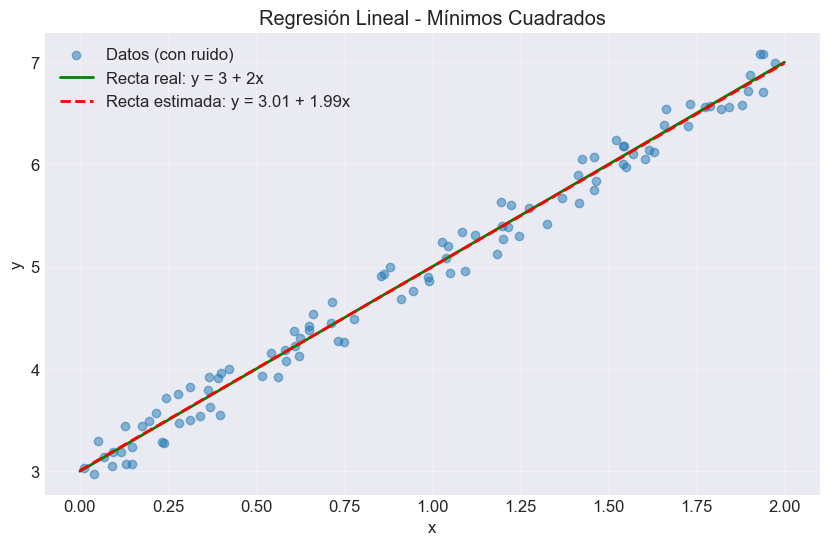

In [25]:
# Crear puntos para la recta teórica (sin ruido)
xl = np.linspace(0, 2, 10)
yl = 3 + 2 * xl  # Recta real

# Crear puntos para la recta estimada
xe = np.linspace(0, 2, 100)
ye = w[0] + w[1] * xe

# Graficar
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Datos (con ruido)')
plt.plot(xl, yl, 'g-', linewidth=2, label='Recta real: y = 3 + 2x')
plt.plot(xe, ye, 'r--', linewidth=2, label=f'Recta estimada: y = {w[0][0]:.2f} + {w[1][0]:.2f}x')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Lineal - Mínimos Cuadrados')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.6 Cálculo de Métricas de Error

In [26]:
# Predicciones del modelo
y_pred = w[0] + w[1] * x

# Error Cuadrático Medio (MSE)
mse = np.mean((y - y_pred) ** 2)

# Raíz del Error Cuadrático Medio (RMSE)
rmse = np.sqrt(mse)

# Coeficiente de determinación R²
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MSE:  0.0212
RMSE: 0.1457
R²:   0.9850


### 3.7 Regresión Polinomial

Generamos datos no lineales para probar regresión polinomial.

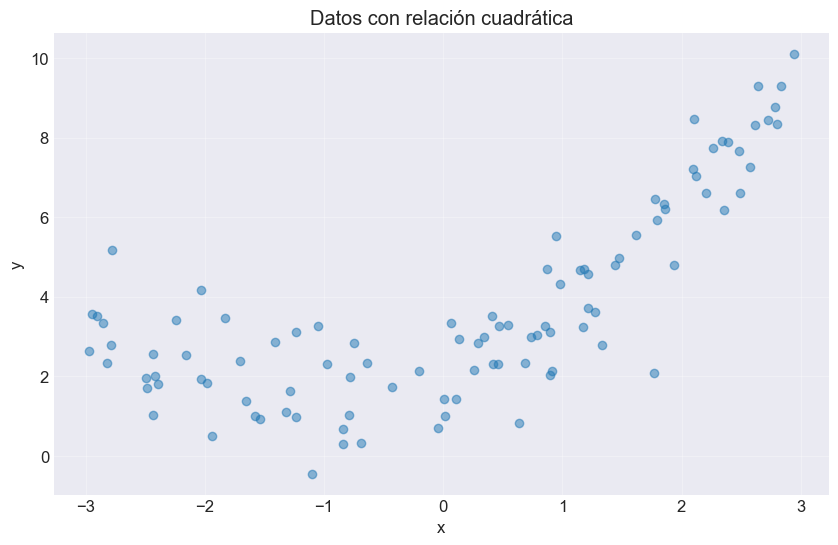

In [27]:
# Generar datos no lineales
m = 100
X_poly = 6 * np.random.rand(m, 1) - 3
Y_poly = 0.5 * X_poly**2 + X_poly + 2 + np.random.randn(m, 1)

plt.scatter(X_poly, Y_poly, alpha=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Datos con relación cuadrática')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# Construir matriz con características polinomiales
# Modelo cuadrático: y = w0 + w1*x + w2*x^2
A_poly = np.c_[np.ones((len(X_poly), 1)), X_poly, X_poly**2]

# Resolver OLS
w_poly = np.linalg.inv(A_poly.T.dot(A_poly)).dot(A_poly.T).dot(Y_poly)

print("Coeficientes del modelo cuadrático:")
print(f"w0 = {w_poly[0][0]:.4f}")
print(f"w1 = {w_poly[1][0]:.4f}")
print(f"w2 = {w_poly[2][0]:.4f}")
print("\nValores reales: w0=2, w1=1, w2=0.5")

Coeficientes del modelo cuadrático:
w0 = 2.0344
w1 = 1.0480
w2 = 0.5099

Valores reales: w0=2, w1=1, w2=0.5


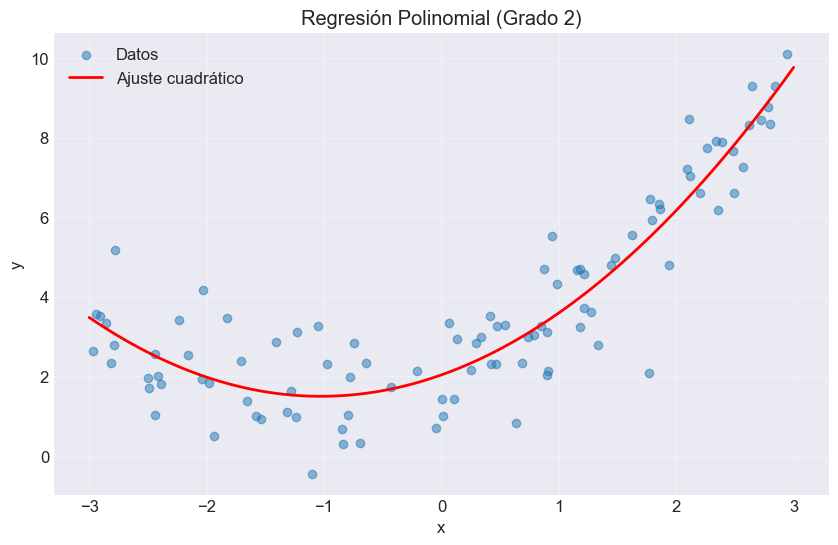

In [29]:
# Visualizar ajuste polinomial
X_plot = np.linspace(-3, 3, 100).reshape(-1, 1)
A_plot = np.c_[np.ones((len(X_plot), 1)), X_plot, X_plot**2]
Y_plot = A_plot.dot(w_poly)

plt.figure(figsize=(10, 6))
plt.scatter(X_poly, Y_poly, alpha=0.5, label='Datos')
plt.plot(X_plot, Y_plot, 'r-', linewidth=2, label='Ajuste cuadrático')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regresión Polinomial (Grado 2)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3.8 Sobreajuste (Overfitting) en Regresión Polinomial

Probemos con polinomios de mayor grado y observemos el comportamiento.

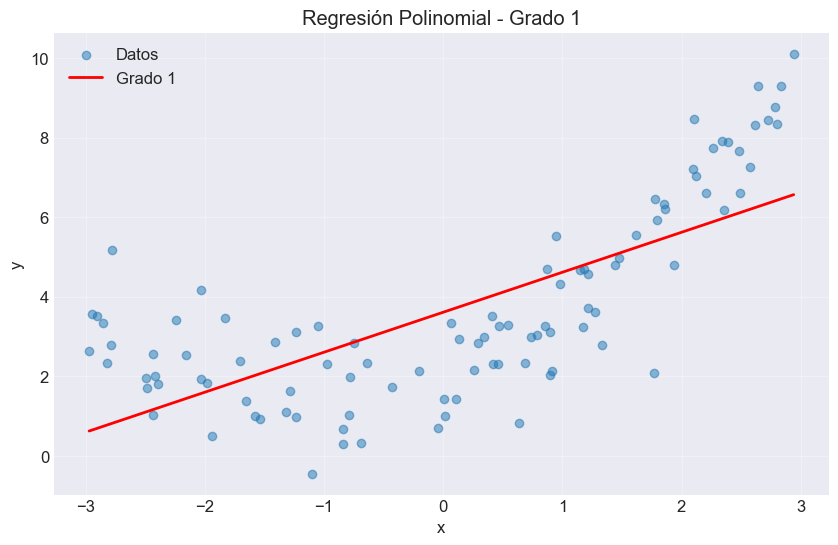

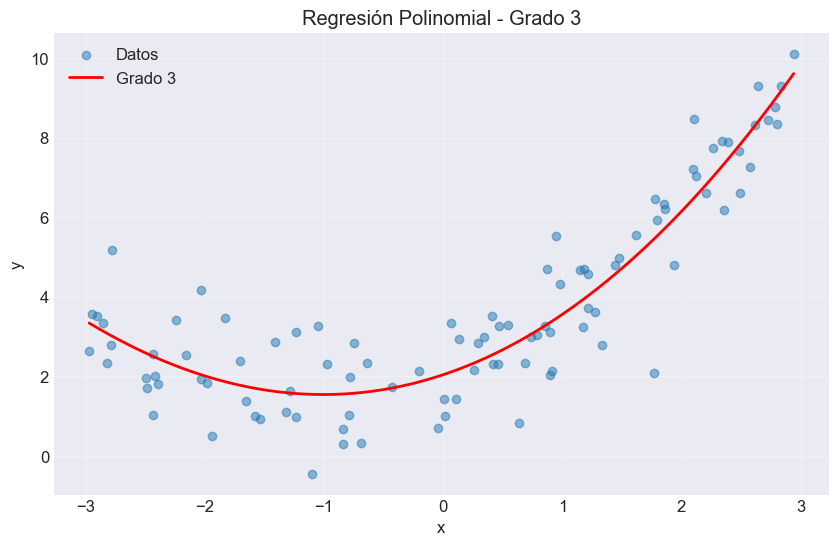

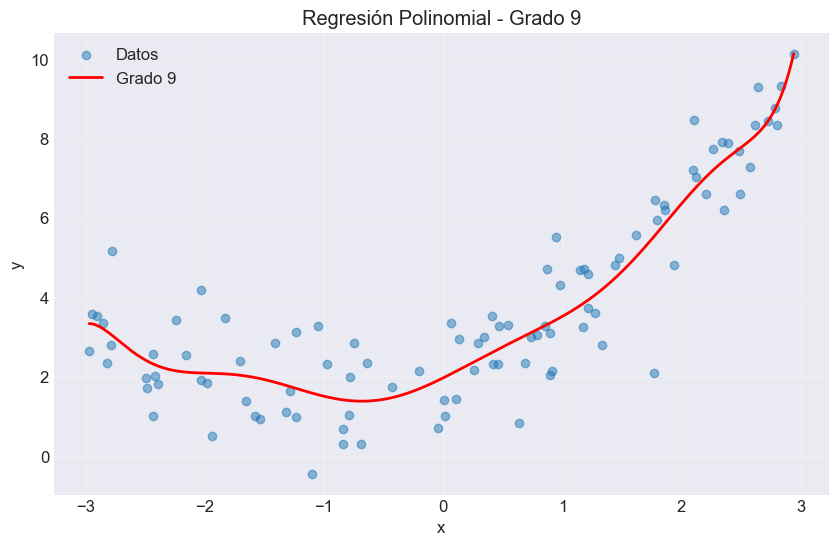

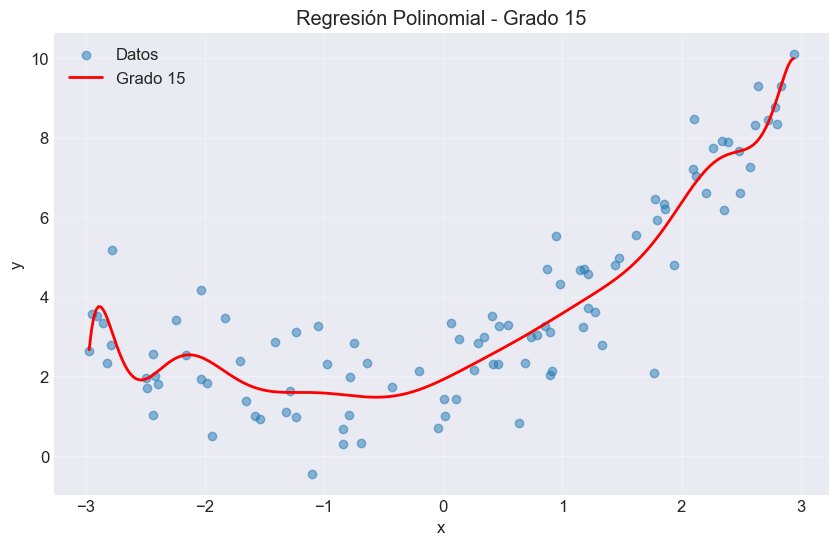

In [30]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

def plot_polynomial_fit(degree, X, y):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X, y)

    X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_plot = model.predict(X_plot)

    plt.scatter(X, y, alpha=0.5, label='Datos')
    plt.plot(X_plot, y_plot, 'r-', linewidth=2, label=f'Grado {degree}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(f'Regresión Polinomial - Grado {degree}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Probar con diferentes grados
degrees = [1, 3, 9, 15]

for d in degrees:
    plot_polynomial_fit(d, X_poly, Y_poly)

**Observaciones:**
*   Grado 1: Subajuste (underfitting) - no captura la curvatura.
*   Grado 3: Buen ajuste - captura la tendencia general.
*   Grado 9 y 15: Sobreajuste (overfitting) - el modelo se ajusta demasiado al ruido.

**Coeficientes para grado 9 (ejemplo):**

| Coeficiente | Valor |
|:---:|---:|
| $w_0$ | 0.35 |
| $w_1$ | 232.37 |
| $w_2$ | -5321.83 |
| $w_3$ | 48568.31 |
| ... | ... |
| $w_9$ | 125201.43 |

## 4. 📝 Ejercicios Propuestos

### Ejercicio 1: Regresión Lineal Simple

Genera un conjunto de datos con la relación $y = 5 - 1.5x + \epsilon$, donde $\epsilon$ es ruido gaussiano con media 0 y desviación estándar 0.3. Aplica OLS y calcula:
*   Los coeficientes estimados
*   El MSE y R²
*   Grafica los datos y la recta de regresión

### Ejercicio 2: Regresión Polinomial

Genera datos con la función $y = \sin(x) + \epsilon$ para $x \in [0, 2\pi]$. Ajusta polinomios de grado 3, 6 y 10. ¿Cuál generaliza mejor? ¿Cómo lo determinarías?

### Ejercicio 3: Validación Cruzada

Para el ejercicio anterior, divide los datos en entrenamiento (70%) y prueba (30%). Calcula el error en ambos conjuntos para cada grado. ¿Qué observas sobre el sobreajuste?

## 5. 📚 Recursos Adicionales

*   🔗 [ANDE - Demanda del Sistema Interconectado Nacional](https://www.ande.gov.py/)
*   🔗 [Scikit-learn: Polynomial Features](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)
*   🔗 [Understanding R²](https://en.wikipedia.org/wiki/Coefficient_of_determination)
*   🔗 [Overfitting in Machine Learning](https://en.wikipedia.org/wiki/Overfitting)

---

